In [15]:
import numpy as np
import seaborn as sns
import pandas as pd
# Data
X_train = np.array([
    [1, 2],
    [2, 3],
    [3, 3],
    [6, 5],
    [7, 7]
])

y_train = np.array([0, 0, 0, 1, 1])

X_test = np.array([
    [2, 2],
    [6, 6]
])

<Axes: xlabel='x1', ylabel='x2'>

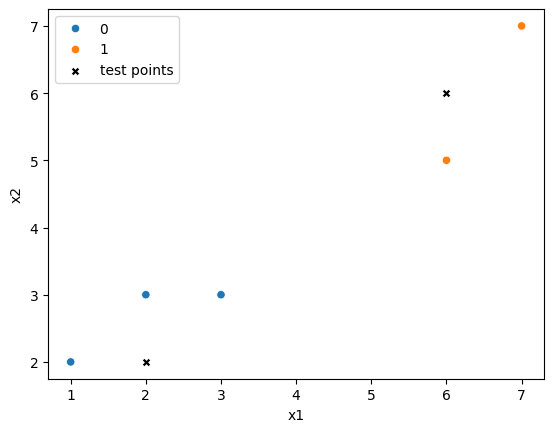

In [17]:
X_train_df=pd.DataFrame(X_train,columns=["x1","x2"])
X_train_df["label"]=y_train

sns.scatterplot(
    data=X_train_df,
    x="x1",
    y="x2",
    hue="label",
)

X_test_df=pd.DataFrame(X_test,columns=["x1","x2"])


sns.scatterplot(
    data=X_test_df,
    x="x1",
    y="x2",
    color="black",
    marker="X",
    label="test points"
)



In [20]:
class KNNclassifier:
    def __init__(self, k=3):
        self.k = k

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def euclidean_distance(self, X1, X2):
        return np.sqrt(np.sum((X1 - X2) ** 2))

    def predict_one(self, X):
        distances = []

        for x in self.X_train:
            distance = self.euclidean_distance(x, X)
            distances.append(distance)


        knn_indices = np.argsort(distances)[:self.k]


        knn_classes = [self.y_train[i] for i in knn_indices]


        most_common = np.bincount(knn_classes).argmax()

        return most_common

    def predict(self, X):
        return np.array([self.predict_one(x) for x in X])





In [21]:
model=KNNclassifier()
model.fit(X_train,y_train)

print(model.predict(X_test))



[0 1]
